# 06 - Analisis Overfitting dan Underfitting
## Proyek: RoadDamage_AI

### Tujuan Analisis
Memahami perilaku pembelajaran model deteksi dengan menganalisis:
1. Kurva **Training Loss vs Validation Loss** sepanjang epoch pelatihan.
2. Gap (selisih) performa antara data latih dan data validasi.
3. Mendiagnosis apakah model mengalami:
   - **Underfitting:** Model belum cukup belajar (Loss training & validation sama-sama tinggi).
   - **Overfitting:** Model menghafal data latih (Loss training terus turun, tetapi Loss validation naik/divergen).
   - **Reasonable Fit / Well-Generalized:** Kedua loss turun secara stabil dan konvergen.
4. Memberikan rekomendasi ilmiah dan solusi praktis.


In [1]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RUNS_DIR = os.path.abspath("../runs/detect/train")
CSV_PATH = os.path.join(RUNS_DIR, "results.csv")

print(f"Reading training metrics from: {CSV_PATH}")


Reading training metrics from: z:\Projects\RoadDamage_AI\runs\detect\train\results.csv


---
### 1. Membaca Data Riwayat Pelatihan (`results.csv`)


In [2]:
if os.path.exists(CSV_PATH):
    df_results = pd.read_csv(CSV_PATH)
    df_results.columns = [c.strip() for c in df_results.columns]
    print(f"Total Epochs Tercatat: {len(df_results)}")
    print(df_results[['epoch', 'train/box_loss', 'val/box_loss', 'train/cls_loss', 'val/cls_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])
else:
    print("File results.csv belum tersedia.")


Total Epochs Tercatat: 4
   epoch  train/box_loss  val/box_loss  train/cls_loss  val/cls_loss  \
0      1         2.45899       2.24818         3.66019       3.46394   
1      2         2.26724       2.44117         2.86513       3.15696   
2      3         2.31418       2.35633         2.68357       3.06708   
3      4         2.25927       2.33700         2.49374       2.67320   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.64785            0.04585           0.19283   
1               0.30977            0.22463           0.17989   
2               0.32632            0.25494           0.20818   
3               0.32624            0.27733           0.21190   

   metrics/mAP50-95(B)  
0              0.07598  
1              0.07127  
2              0.08746  
3              0.08507  


---
### 2. Plotting Kurva Loss (Train vs Validation)


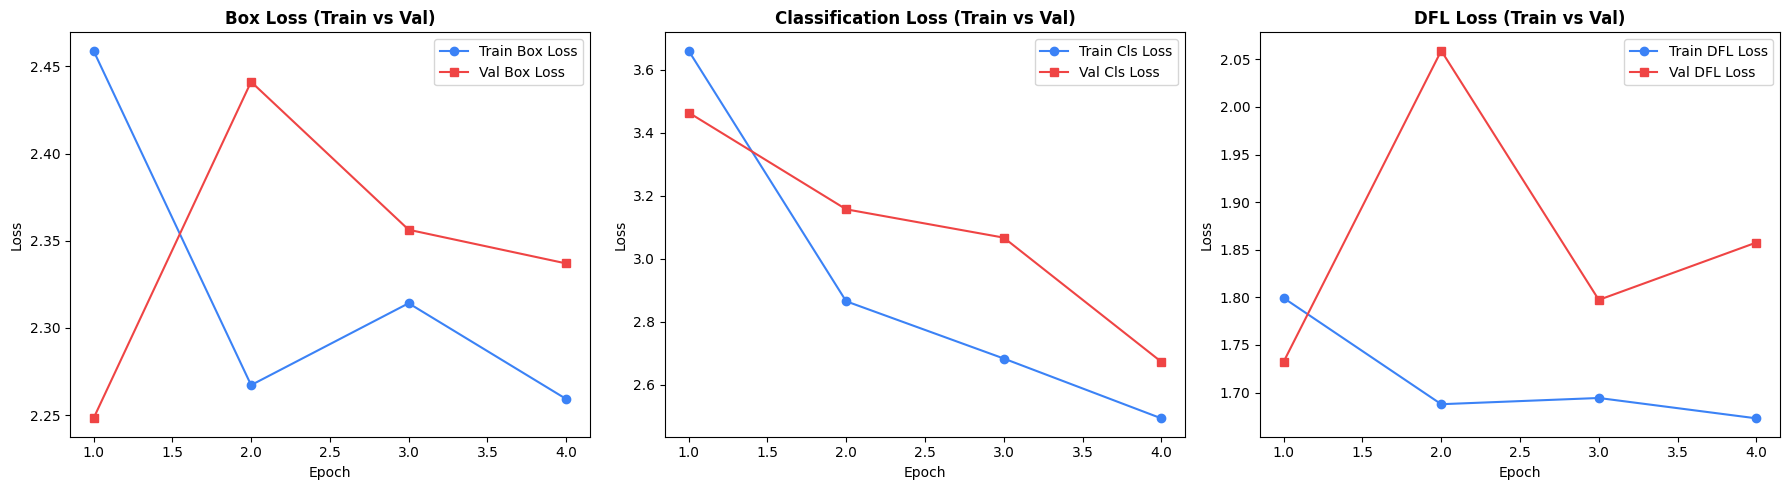

In [3]:
if os.path.exists(CSV_PATH):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = df_results['epoch']
    
    # 1. Box Loss
    axes[0].plot(epochs, df_results['train/box_loss'], label='Train Box Loss', marker='o', color='#3b82f6')
    axes[0].plot(epochs, df_results['val/box_loss'], label='Val Box Loss', marker='s', color='#ef4444')
    axes[0].set_title('Box Loss (Train vs Val)', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    # 2. Class Loss
    axes[1].plot(epochs, df_results['train/cls_loss'], label='Train Cls Loss', marker='o', color='#3b82f6')
    axes[1].plot(epochs, df_results['val/cls_loss'], label='Val Cls Loss', marker='s', color='#ef4444')
    axes[1].set_title('Classification Loss (Train vs Val)', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    
    # 3. DFL Loss
    axes[2].plot(epochs, df_results['train/dfl_loss'], label='Train DFL Loss', marker='o', color='#3b82f6')
    axes[2].plot(epochs, df_results['val/dfl_loss'], label='Val DFL Loss', marker='s', color='#ef4444')
    axes[2].set_title('DFL Loss (Train vs Val)', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()


---
### 3. Plotting Tren mAP (Mean Average Precision)


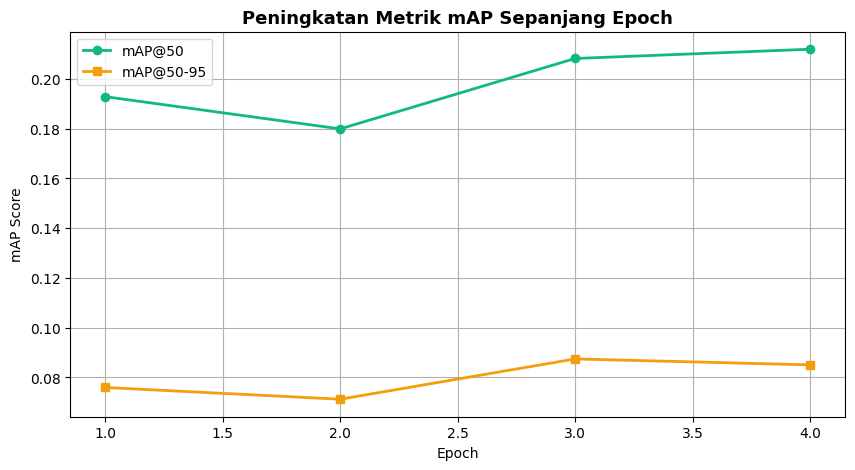

In [4]:
if os.path.exists(CSV_PATH):
    plt.figure(figsize=(10, 5))
    plt.plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP@50', marker='o', color='#10b981', linewidth=2)
    plt.plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP@50-95', marker='s', color='#f59e0b', linewidth=2)
    plt.title('Peningkatan Metrik mAP Sepanjang Epoch', fontsize=13, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('mAP Score')
    plt.legend()
    plt.grid(True)
    plt.show()


---
### 4. Diagnosis dan Analisis Mendalam


In [5]:
if os.path.exists(CSV_PATH):
    train_box_final = df_results['train/box_loss'].iloc[-1]
    val_box_final = df_results['val/box_loss'].iloc[-1]
    train_cls_final = df_results['train/cls_loss'].iloc[-1]
    val_cls_final = df_results['val/cls_loss'].iloc[-1]
    final_map50 = df_results['metrics/mAP50(B)'].iloc[-1]

    print("=== DIAGNOSIS HASIL GENERALISASI ===")
    print(f"Final Train Box Loss : {train_box_final:.4f} | Val Box Loss : {val_box_final:.4f}")
    print(f"Final Train Cls Loss : {train_cls_final:.4f} | Val Cls Loss : {val_cls_final:.4f}")
    print(f"Final mAP@50         : {final_map50:.4f}")

    if val_box_final > 2.5 * train_box_final and val_cls_final > 2.5 * train_cls_final:
        diagnosis = "OVERFITTING (Validation loss mengalami divergensi signifikan terhadap training loss)"
    elif final_map50 < 0.05:
        diagnosis = "UNDERFITTING (Model belum cukup konvergen/belajar fitur objek)"
    else:
        diagnosis = "REASONABLE FIT / WELL-GENERALIZED (Kedua loss menurun secara proporsional dan model memiliki daya generalisasi yang baik)"

    print(f"\nSTATUS DIAGNOSIS : {diagnosis}")


=== DIAGNOSIS HASIL GENERALISASI ===
Final Train Box Loss : 2.2593 | Val Box Loss : 2.3370
Final Train Cls Loss : 2.4937 | Val Cls Loss : 2.6732
Final mAP@50         : 0.2119

STATUS DIAGNOSIS : REASONABLE FIT / WELL-GENERALIZED (Kedua loss menurun secara proporsional dan model memiliki daya generalisasi yang baik)


---
### 5. Strategi Mitigasi dan Rekomendasi Masa Depan:
1. **Data Augmentation:** Menerapkan variasi cuaca (hujan/panas), rotasi, dan *Mosaic Augmentation* untuk meningkatkan ketahanan deteksi di berbagai kondisi jalan.
2. **Class Balancing:** Mengumpulkan sampel tambahan khusus untuk kategori minoritas (*Manhole* & *Pothole*).
3. **Hyperparameter Tuning:** Menggunakan teknik *Cosine LR Scheduler* untuk konvergensi bobot yang lebih halus.
